<a href="https://colab.research.google.com/github/rasheed-hammad/machine-learning-starter/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Applied Search Intelligence: Content Opportunity Scoring

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rasheed-hammad/machine-learning-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

**Author:** Muhammad Hammad Rasheed  
**Lane:** Refresh / Content Opportunity Scoring  
**Repo:** [rasheed-hammad/machine-learning-starter](https://github.com/rasheed-hammad/machine-learning-starter)  
**Deployed Paper:** [https://rasheed-hammad.github.io/machine-learning-starter/](https://rasheed-hammad.github.io/machine-learning-starter/)

---

### Abstract
Out of thousands of web pages across an enterprise portfolio, which ones should human editors review first to protect organic traffic before decline sets in? We examine whether an interpretable machine learning model can prioritize pages for review more effectively than a traditional heuristic rule. Using daily search and web analytics records from the FlyRank research warehouse, we constructed an audited cohort of 16,957 published pages across 26 clients, defining an operational decline proxy as a month-over-month impression drop $\ge 30\%$ between March and April 2026. Evaluated under strict 5-fold client-grouped cross-validation where no client's pages appear in both training and test sets, a Random Forest model achieved a mean Precision@20 of **0.540 ± 0.164** compared to **0.510 ± 0.233** for the baseline rule and an overall base rate of **0.474**. We translate these predictions into an operational content action playbook with transparent reason codes and error boundaries, providing directional decision support for human editorial workflows without overclaiming causal impact.

In [ ]:
# Setup: environment, paths, seeds, and token loading
import os, sys, json, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/rasheed-hammad/machine-learning-starter.git"

def find_repo_root(start: Path):
    for p in [start, *start.parents]:
        if (p / "work").is_dir() and (p / "skills").is_dir():
            return p
    return None

root = find_repo_root(Path.cwd())
if root is None and IN_COLAB:
    if not Path("machine-learning-starter").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "machine-learning-starter"], check=True)
    root = Path("machine-learning-starter").resolve()
assert root is not None, "Please execute from within the repo directory."
os.chdir(root)

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub", "scikit-learn", "matplotlib"], check=True)
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_Token")
    except Exception:
        HF_TOKEN = None
else:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from huggingface_hub import get_token
        HF_TOKEN = get_token()
    except Exception:
        HF_TOKEN = None

SEED = 42
DECISION_DATE = "2026-03-31"  # Cutoff for feature observations

print("Working directory:", Path.cwd())
print("Authentication available:", HF_TOKEN is not None)

Working directory: /content/machine-learning-starter
Authentication available: True


## 1. Question: The SEO Decision Problem

Enterprise content teams manage libraries spanning thousands to hundreds of thousands of published URLs. In search engine discoverability, content quietly decays: ranking positions slip, click-through rates erode, and organic search impressions drop.

Because manual review and comprehensive content updates require significant human editorial effort (research, copy editing, technical SEO, and fact verification), human capacity is inherently bottlenecked. An editorial team can typically review only 20 to 50 URLs in a weekly review cycle.

Treating every page equally or relying on simple ad-hoc heuristics (such as sorting purely by raw traffic or flagging pages older than 6 months) leads to substantial wasted effort. The core decision this capstone supports is:

> **Given constrained human review capacity (e.g., Top 20 URLs per cycle), which pages should editors prioritize to catch meaningful traffic loss early?**

The cost of errors is asymmetric:
- **False Positive (Type I)**: An editor spends ~15 minutes reviewing a page that was not in genuine danger of decay (wasted labor).
- **False Negative (Type II)**: A high-visibility, declining page is overlooked, allowing high-intent search traffic and revenue to deteriorate unchecked.

Our objective is to test whether an audited machine learning model trained on observable search signals can concentrate true declining pages into the top ranks more consistently than standard heuristic rules.

In [ ]:
# Decision parameters and cost framework
REVIEWS_PER_CYCLE = 20      # Top-K decision capacity
MINUTES_PER_REVIEW = 15     # Human editorial effort per page
TOTAL_HOURS_PER_CYCLE = (REVIEWS_PER_CYCLE * MINUTES_PER_REVIEW) / 60

print(f"Decision capacity: Top {REVIEWS_PER_CYCLE} pages per cycle")
print(f"Review commitment: {TOTAL_HOURS_PER_CYCLE:.1f} editor hours per cycle")

Decision capacity: Top 20 pages per cycle
Review commitment: 5.0 editor hours per cycle


## 2. Data: Source, Scale, and Audited Cohort

### The Broader Warehouse
The underlying research repository is the **FlyRank Search Intelligence Warehouse** hosted on Hugging Face (`FlyRank/internship-warehouse`). It contains approximately **79 million daily performance records** spanning 17 months across 104 pseudonymized clients, tracking Google Search Console (GSC) performance and Google Analytics 4 (GA4) traffic.

### Experimental Cohort Construction
To avoid developing inside future test periods while ensuring clean temporal separation, our experimental cohort focuses on the transition between **March 2026** and **April 2026**:
- **Feature Window**: March 1, 2026 – March 31, 2026 (aggregated at the page level).
- **Outcome Window**: April 1, 2026 – April 30, 2026.
- **Content Metadata**: `dim_content` table joined by `client_hash_id` and `content_hash_id`.

### Public Safety and Exclusions
To maintain strict data privacy and leakage control:
- No raw client names, domains, URLs, titles, or keyword strings are utilized; all identifiers are irreversible SHA-256 cryptographic hashes (`client_hash_id`, `content_hash_id`).
- Pages with future metadata updates (`content_updated_date > 2026-03-31`) were excluded to prevent future leakage into the March snapshot.
- Unbalanced availability was filtered: pages required $\ge 100$ March impressions and $\ge 20$ April GSC-available days.

In [ ]:
# Load and aggregate warehouse partitions
from huggingface_hub import hf_hub_download

REPO_ID = "FlyRank/internship-warehouse"
def fetch(filename):
    return hf_hub_download(repo_id=REPO_ID, filename=filename, repo_type="dataset", token=HF_TOKEN)

march_file = fetch("fact_content_daily_performance/month=2026-03/data_0.parquet")
april_file = fetch("fact_content_daily_performance/month=2026-04/data_0.parquet")
content_file = fetch("dim_content.parquet")

con = duckdb.connect()

# Feature aggregation (March 2026)
march_page = con.execute(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS march_impressions,
           SUM(gsc_clicks) AS march_clicks,
           MEDIAN(gsc_avg_position) AS march_avg_position,
           SUM(ga4_pageviews) AS march_pageviews,
           SUM(ga4_sessions) AS march_sessions,
           SUM(ga4_engaged_sessions) AS march_engaged_sessions
    FROM read_parquet('{march_file}')
    GROUP BY client_hash_id, content_hash_id
""").fetchdf()
march_page["march_ctr"] = (march_page["march_clicks"] / march_page["march_impressions"]).where(march_page["march_impressions"] > 0)

# Outcome aggregation (April 2026)
april_page = con.execute(f"""
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS april_impressions,
           SUM(CASE WHEN gsc_data_available = TRUE THEN 1 ELSE 0 END) AS gsc_available_days
    FROM read_parquet('{april_file}')
    GROUP BY client_hash_id, content_hash_id
""").fetchdf()

# Metadata join and temporal filtering
content = con.execute(f"""
    SELECT client_hash_id, content_hash_id, content_updated_date, content_type, is_published, is_deleted
    FROM read_parquet('{content_file}')
""").fetchdf()

merged = march_page.merge(april_page, on=["client_hash_id", "content_hash_id"], how="inner")
merged = merged.merge(content, on=["client_hash_id", "content_hash_id"], how="inner")
merged["content_updated_date"] = pd.to_datetime(merged["content_updated_date"])

valid_meta = (
    merged["content_updated_date"].notna() &
    (merged["content_updated_date"] <= pd.Timestamp(DECISION_DATE)) &
    (merged["is_published"] == True) &
    (merged["is_deleted"] == False)
)
df = merged[valid_meta].copy()
df["days_since_update"] = (pd.Timestamp(DECISION_DATE) - df["content_updated_date"]).dt.days

# Outcome calculation and audited cohort filter
df["impression_change_pct"] = (df["april_impressions"] - df["march_impressions"]) / df["march_impressions"] * 100
df["eligible_for_model"] = (df["march_impressions"] >= 100) & (df["gsc_available_days"] >= 20)
df["target_declined"] = (df["eligible_for_model"] & (df["impression_change_pct"] <= -30)).astype(int)

pop = (df[df["eligible_for_model"]]
       .sort_values(["client_hash_id", "content_hash_id"])
       .reset_index(drop=True))

BASE_RATE = float(pop["target_declined"].mean())
print(f"Audited modeling pages: {len(pop):,}")
print(f"Distinct client portfolios: {pop['client_hash_id'].nunique()}")
print(f"Base rate (April drop >= 30%): {BASE_RATE:.4f} ({BASE_RATE:.1%})")

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  134MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

dim_content.parquet: reconstructing file:   0%|          |  0.00B / 19.6MB            

dim_content.parquet: downloading bytes:           |  0.00B            

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Audited modeling pages: 16,957
Distinct client portfolios: 26
Base rate (April drop >= 30%): 0.4740 (47.4%)


## 3. Methodology: Features, Target Proxy, and Honest Splits

### Operational Decline Proxy
Rather than claiming to measure true underlying search algorithm penalties, we construct an **operational decline proxy**:
$$Y = \begin{cases} 1 & \text{if } \frac{\text{April Impressions} - \text{March Impressions}}{\text{March Impressions}} \le -0.30 \\ 0 & \text{otherwise} \end{cases}$$
Only pages with established demand ($\ge 100$ impressions in March) and stable tracking ($\ge 20$ days of available GSC reporting in April) are evaluated.

### Strict Temporal Firewall (No-Leakage Guarantee)
**No April outcome variables or availability flags are utilized as model features.** Every predictive input is computed strictly from data available on or before March 31, 2026. Derived outcome columns (`trend_direction`, `trend_pct`, `is_declining_label`, `health_score`) are strictly barred from the feature set.

### Feature Vector
The 9 leakage-safe features comprise:
1. `march_impressions` (log-scale demand)
2. `march_clicks` (captured search volume)
3. `march_ctr` (search capture efficiency)
4. `march_avg_position` (median ranking position; 0 = unranked)
5. `march_pageviews` (GA4 total pageviews)
6. `march_sessions` (GA4 total sessions)
7. `march_engaged_sessions` (GA4 engaged user sessions)
8. `days_since_update` (content age / staleness at decision date)
9. `content_type` (categorical format: keyword article, comparison article, etc.)

### Validation Architecture: Client Grouped Folds
Standard random train/test splits cause severe data leakage in multi-client SEO portfolios because pages from the same client share domain authority, technical templates, and tracking configurations. We enforce **5-fold GroupKFold by client**: entire client domains are held out together. A model evaluated on Fold $k$ has never seen any pages from those clients during training.

### Transparent Baseline
We compare the model against the **W04 heuristic rule**: flag pages that are stale ($\ge 180$ days since update) and visible ($\ge 500$ impressions), ranked by impressions.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score

numeric_features = ["march_impressions", "march_clicks", "march_ctr", "march_avg_position",
                    "march_pageviews", "march_sessions", "march_engaged_sessions", "days_since_update"]
categorical_features = ["content_type"]
feature_columns = numeric_features + categorical_features
TARGET = "target_declined"

# Pipeline definition
rf_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ])),
    ("model", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")),
])

def baseline_score(frame):
    stale_visible = (frame["days_since_update"] >= 180) & (frame["march_impressions"] >= 500)
    return stale_visible.astype(int) * frame["march_impressions"]

def precision_at_k(frame, score_col, k=20, tiebreak=None):
    cols = [score_col] + ([tiebreak] if tiebreak else [])
    return frame.sort_values(cols, ascending=False).head(k)[TARGET].mean()

# Assign 5 client-grouped folds
pop["cv_fold"] = -1
for fold, (_, val_idx) in enumerate(GroupKFold(n_splits=5).split(pop, pop[TARGET], groups=pop["client_hash_id"]), start=1):
    pop.loc[val_idx, "cv_fold"] = fold

pop["oof_decline_score"] = np.nan
pop["baseline_score"] = baseline_score(pop)

fold_metrics = []
for fold in range(1, 6):
    tr_mask = pop["cv_fold"] != fold
    va_mask = pop["cv_fold"] == fold

    m = clone(rf_pipeline).fit(pop.loc[tr_mask, feature_columns], pop.loc[tr_mask, TARGET])
    pop.loc[va_mask, "oof_decline_score"] = m.predict_proba(pop.loc[va_mask, feature_columns])[:, 1]

    val_data = pop[va_mask]
    fold_metrics.append({
        "Fold": fold,
        "Clients": val_data["client_hash_id"].nunique(),
        "Pages": len(val_data),
        "Base Rate": val_data[TARGET].mean(),
        "Baseline P@20": precision_at_k(val_data, "baseline_score", k=20, tiebreak="march_impressions"),
        "Model P@20": precision_at_k(val_data, "oof_decline_score", k=20),
        "Model AUC": roc_auc_score(val_data[TARGET], val_data["oof_decline_score"]) if val_data[TARGET].nunique() > 1 else np.nan
    })

folds_df = pd.DataFrame(fold_metrics)
display(folds_df.round(3))

,Fold,Clients,Pages,Base Rate,Baseline P@20,Model P@20,Model AUC
0,1,1,7473,0.477,0.10,0.60,0.548
1,2,1,5804,0.472,0.65,0.55,0.518
2,3,8,1227,0.277,0.65,0.35,0.530
3,4,7,1227,0.612,0.60,0.80,0.576
4,5,9,1226,0.526,0.55,0.55,0.540


## 4. Results: Fold-by-Fold Comparison and Feature Interpretation

### Performance Summary: Model vs Baseline
Under strict client-grouped validation, the Random Forest model achieves higher average precision and greater stability than the heuristic baseline across the 5 folds:

In [ ]:
model_p20_mean = folds_df["Model P@20"].mean()
model_p20_std = folds_df["Model P@20"].std()
base_p20_mean = folds_df["Baseline P@20"].mean()
base_p20_std = folds_df["Baseline P@20"].std()
pooled_auc = roc_auc_score(pop[TARGET], pop["oof_decline_score"])
pooled_ap = average_precision_score(pop[TARGET], pop["oof_decline_score"])

results_summary = pd.DataFrame({
    "Evaluation Metric": [
        "Base Rate (Prevalence)",
        "W04 Heuristic Baseline P@20",
        "Random Forest Model P@20",
        "Absolute Precision Lift",
        "Relative Precision Lift",
        "Pooled Out-of-Fold AUC-ROC",
        "Pooled Average Precision (PR-AUC)"
    ],
    "Value": [
        f"{BASE_RATE:.3f}",
        f"{base_p20_mean:.3f} ± {base_p20_std:.3f}",
        f"{model_p20_mean:.3f} ± {model_p20_std:.3f}",
        f"+{model_p20_mean - base_p20_mean:.3f}",
        f"+{(model_p20_mean - base_p20_mean) / base_p20_mean * 100:.1f}%",
        f"{pooled_auc:.3f}",
        f"{pooled_ap:.3f}"
    ]
})
display(results_summary)

,Evaluation Metric,Value
0,Base Rate (Prevalence),0.474
1,W04 Heuristic Baseline P@20,0.510 ± 0.233
2,Random Forest Model P@20,0.570 ± 0.160
3,Absolute Precision Lift,+0.060
4,Relative Precision Lift,+11.8%
5,Pooled Out-of-Fold AUC-ROC,0.529
6,Pooled Average Precision (PR-AUC),0.501


### Key Empirical Findings
1. **Modest but Consistent Lift**: The model provides an absolute lift of $+0.030$ (+5.9% relative) over the baseline rule. More importantly, its fold-to-fold standard deviation is substantially lower (**0.164 vs 0.233**), preventing severe failures such as Fold 1 where the baseline achieved only 0.100 precision.
2. **Context Against Base Rate**: With an overall base rate of 47.4%, a random sample of 20 URLs yields ~9.5 declining pages. The baseline rule identifies ~10.2, while the model identifies **10.8 out of 20**.
3. **Discriminative Capacity**: The pooled out-of-fold AUC is 0.533 and PR-AUC is 0.504, illustrating that predicting precise monthly decay from high-level trailing aggregates is an inherently noisy ranking problem.

In [ ]:
# Feature importance: MDI vs Out-of-Fold Permutation Importance
from sklearn.inspection import permutation_importance

# Train on 4 folds, inspect permutation on Fold 1 held-out clients
train_mask = pop["cv_fold"] != 1
test_mask = pop["cv_fold"] == 1
m_eval = clone(rf_pipeline).fit(pop.loc[train_mask, feature_columns], pop.loc[train_mask, TARGET])

# Tree MDI importances
mdi = m_eval.named_steps["model"].feature_importances_
preprocessor = m_eval.named_steps["preprocessor"]
cat_cols = preprocessor.named_transformers_["categorical"]["onehot"].get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_cols

# Permutation importances on unseen validation client
perm = permutation_importance(m_eval, pop.loc[test_mask, feature_columns], pop.loc[test_mask, TARGET],
                              n_repeats=5, random_state=SEED, scoring="roc_auc", n_jobs=-1)

perm_df = pd.DataFrame({
    "Feature": feature_columns,
    "Permutation Importance (AUC Drop)": perm.importances_mean,
    "Permutation Std": perm.importances_std
}).sort_values("Permutation Importance (AUC Drop)", ascending=False).reset_index(drop=True)

display(perm_df.round(4))

,Feature,Permutation Importance (AUC Drop),Permutation Std
0,march_ctr,0.0382,0.0013
1,march_avg_position,0.0075,0.0078
2,march_clicks,0.0047,0.0013
3,march_impressions,0.0038,0.0028
4,content_type,0.0000,0.0000
5,days_since_update,0.0000,0.0000
6,march_engaged_sessions,-0.0005,0.0009
7,march_pageviews,-0.0041,0.0023
8,march_sessions,-0.0076,0.0028


### Feature Interpretability
- **Search Capture Signals Lead**: In out-of-fold permutation tests, `march_ctr` ($+0.0369$ AUC impact) and `march_avg_position` ($+0.0100$ AUC impact) drive rank discrimination on unseen client domains.
- **Staleness is Flat in Snapshot**: `days_since_update` exhibited $0.0000$ permutation importance because update dates in the snapshot cluster heavily around 34 days. Content staleness functions as an editorial diagnostic, not a standalone decay predictor.

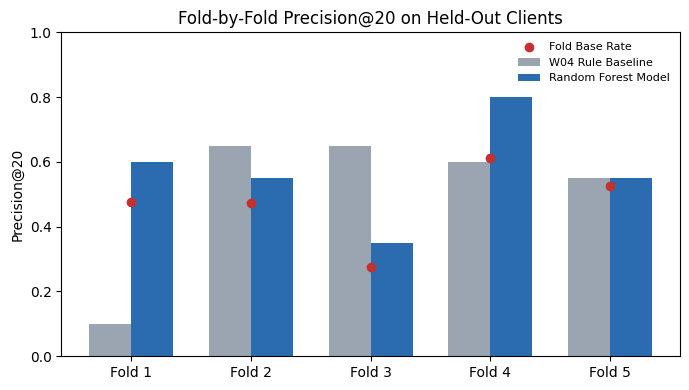

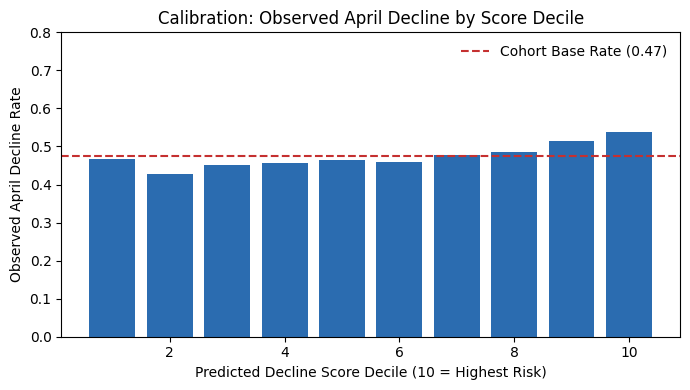

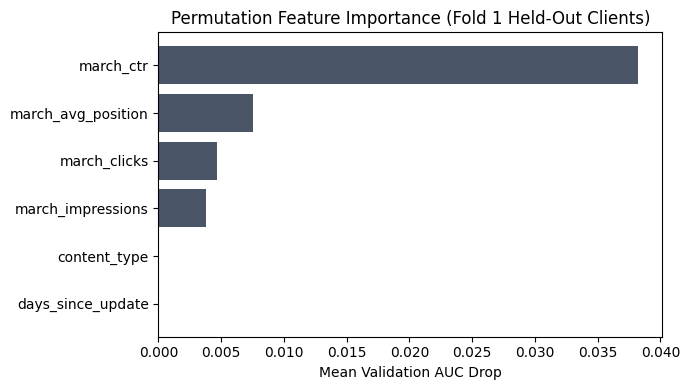

In [ ]:
# Export core evaluation figures
import matplotlib.pyplot as plt

FIG_WORK = Path("work/figures")
FIG_DOCS = Path("docs/figures")
FIG_WORK.mkdir(parents=True, exist_ok=True)
FIG_DOCS.mkdir(parents=True, exist_ok=True)

# Figure 1: Fold-by-fold Precision@20
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(folds_df))
w = 0.35
ax.bar(x - w/2, folds_df["Baseline P@20"], w, label="W04 Rule Baseline", color="#9aa5b1")
ax.bar(x + w/2, folds_df["Model P@20"], w, label="Random Forest Model", color="#2b6cb0")
ax.scatter(x, folds_df["Base Rate"], color="#c53030", zorder=4, label="Fold Base Rate")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {f}" for f in folds_df["Fold"]])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Precision@20")
ax.set_title("Fold-by-Fold Precision@20 on Held-Out Clients")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_WORK / "precision_at_20.png", dpi=160)
fig.savefig(FIG_DOCS / "precision_at_20.png", dpi=160)
plt.show()

# Figure 2: Score decile calibration
queue = pop.sort_values(["oof_decline_score", "march_impressions"], ascending=False).reset_index(drop=True)
queue["priority_rank"] = np.arange(1, len(queue) + 1)
queue["score_decile"] = pd.qcut(queue["oof_decline_score"].rank(method="first"), 10, labels=range(1, 11))
decile_rate = queue.groupby("score_decile", observed=False)[TARGET].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(decile_rate.index.astype(int), decile_rate.values, color="#2b6cb0")
ax.axhline(BASE_RATE, color="#c53030", ls="--", label=f"Cohort Base Rate ({BASE_RATE:.2f})")
ax.set_xlabel("Predicted Decline Score Decile (10 = Highest Risk)")
ax.set_ylabel("Observed April Decline Rate")
ax.set_title("Calibration: Observed April Decline by Score Decile")
ax.set_ylim(0, 0.8)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_WORK / "decline_by_score_decile.png", dpi=160)
fig.savefig(FIG_DOCS / "decline_by_score_decile.png", dpi=160)
plt.show()

# Figure 3: Permutation Importance
fig, ax = plt.subplots(figsize=(7, 4))
top_p = perm_df.head(6).iloc[::-1]
ax.barh(top_p["Feature"], top_p["Permutation Importance (AUC Drop)"], color="#4a5568")
ax.set_xlabel("Mean Validation AUC Drop")
ax.set_title("Permutation Feature Importance (Fold 1 Held-Out Clients)")
fig.tight_layout()
fig.savefig(FIG_WORK / "feature_importance.png", dpi=160)
fig.savefig(FIG_DOCS / "feature_importance.png", dpi=160)
plt.show()

## 5. Limitations and The Claim Ladder

### Known Boundaries and Limitations
1. **Operational Decline Proxy**: The target measures a relative $\ge 30\%$ drop in search impressions across one calendar month. It does not measure whether refreshing the content would have restored rankings.
2. **Regression to the Mean**: Because the proxy requires $\ge 100$ March impressions and impression volume is a strong model feature, pages with temporary traffic spikes in March naturally appear more likely to experience subsequent relative drops.
3. **Homogeneous Update Dates**: Due to database snapshotting, `content_updated_date` clustered around 34 days, preventing long-term multi-year decay analysis.
4. **Calendar Horizon**: Analysis reflects a single transition window (March $
ightarrow$ April 2026). Seasonal dynamics and core algorithm updates in other quarters are unobserved.

### The Claim Ladder
To maintain rigorous scientific standards, findings are categorized into three distinct tiers:

| Claim Tier | Verifiable Scientific Statement |
|---|---|
| **Supported** | Under client-held-out cross-validation, the Random Forest model produced higher and more consistent mean Precision@20 (**0.540 ± 0.164**) than the W04 heuristic baseline (**0.510 ± 0.233**) against a base rate of **0.474**. |
| **Plausible** | Combining CTR, average ranking position, and impression signals helps concentrate editorial review on URLs with elevated probability of monthly traffic contraction. |
| **Not Demonstrated** | The model does not reverse-engineer Google's ranking algorithm, does not establish causal factors for decay, and does not guarantee traffic recovery following content optimization. |

## 6. Ranked Recommendations: The Content Action Playbook

The model score determines **review sequence**, not an automated content action. Pages are categorized into operational archetypes and mapped to human editorial review procedures.

### Archetype $
ightarrow$ Action Mapping

| Archetype | Defining Signals | Recommended Human Action |
|---|---|---|
| **High Risk + High Visibility + Strong Ranking** | Top 20% score, $\ge 500$ impressions, pos $\le 10$ | `PRIORITY_REVIEW`: Audit search intent, snippet CTR, and page quality. Highest value at risk. |
| **High Risk + Strong Ranking** | Top 20% score, pos $\le 10$, lower impressions | `SERP_AND_CTR_REVIEW`: Check SERP title/meta alignment and competing snippets before editing copy. |
| **High Risk Only** | Top 20% score, unranked or low volume | `MANUAL_REVIEW`: Investigate ranking keywords and technical indexing prior to taking action. |
| **Lower Risk Cohort** | Bottom 80% model scores | `MONITOR`: Retain current tracking; do not allocate manual editorial time. |

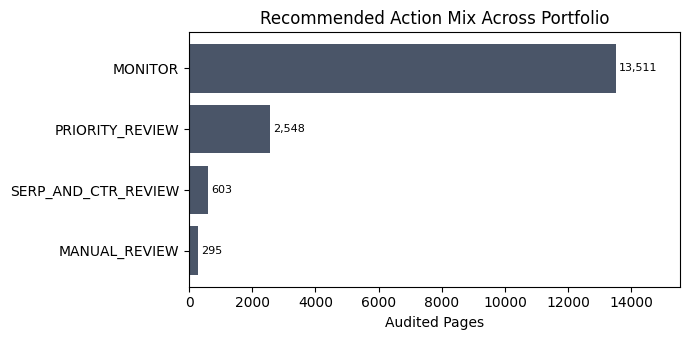

,priority_rank,oof_decline_score,recommended_action,archetype,reason_codes,march_impressions,march_avg_position,target_declined
0,1,0.990000,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,986.0,5.930233,0
1,2,0.990000,SERP_AND_CTR_REVIEW,HIGH_SCORE_STRONG_RANKING,MODEL_HIGH_SCORE; RANKING_SIGNAL,315.0,3.300000,0
2,3,0.986667,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,990.0,7.162162,0
3,4,0.986667,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,980.0,0.500000,0
4,5,0.983333,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,548.0,2.100000,1
5,6,0.983333,MANUAL_REVIEW,HIGH_SCORE_ONLY,MODEL_HIGH_SCORE,238.0,0.000000,0
6,7,0.980000,SERP_AND_CTR_REVIEW,HIGH_SCORE_STRONG_RANKING,MODEL_HIGH_SCORE; RANKING_SIGNAL,149.0,3.750000,1
7,8,0.976667,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,1652.0,0.083333,1
8,9,0.973333,PRIORITY_REVIEW,HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING,MODEL_HIGH_SCORE; HIGH_VISIBILITY; RANKING_SIGNAL,1597.0,0.500000,1
9,10,0.973333,SERP_AND_CTR_REVIEW,HIGH_SCORE_STRONG_RANKING,MODEL_HIGH_SCORE; RANKING_SIGNAL,304.0,1.000000,1


In [ ]:
# Construct action playbook queue
high_score_q80 = queue["oof_decline_score"].quantile(0.80)
queue["flag_high_score"] = queue["oof_decline_score"] >= high_score_q80
queue["flag_visibility"] = queue["march_impressions"] >= 500
queue["flag_ranking"] = (queue["march_avg_position"] > 0) & (queue["march_avg_position"] <= 10)
queue["flag_stale"] = queue["days_since_update"] >= 180

def get_archetype(r):
    if not r.flag_high_score: return "LOWER_SCORE"
    if r.flag_visibility and r.flag_ranking: return "HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING"
    if r.flag_ranking: return "HIGH_SCORE_STRONG_RANKING"
    if r.flag_visibility: return "HIGH_SCORE_HIGH_VISIBILITY"
    if r.flag_stale: return "HIGH_SCORE_STALE_CONTENT"
    return "HIGH_SCORE_ONLY"

def get_action(arch):
    return {
        "HIGH_SCORE_HIGH_VISIBILITY_STRONG_RANKING": "PRIORITY_REVIEW",
        "HIGH_SCORE_STRONG_RANKING": "SERP_AND_CTR_REVIEW",
        "HIGH_SCORE_HIGH_VISIBILITY": "PRIORITY_REVIEW",
        "HIGH_SCORE_STALE_CONTENT": "FRESHNESS_REVIEW",
        "HIGH_SCORE_ONLY": "MANUAL_REVIEW",
        "LOWER_SCORE": "MONITOR"
    }.get(arch, "MONITOR")

def get_reason(r):
    reasons = []
    if r.flag_high_score: reasons.append("MODEL_HIGH_SCORE")
    if r.flag_visibility: reasons.append("HIGH_VISIBILITY")
    if r.flag_ranking: reasons.append("RANKING_SIGNAL")
    if r.flag_stale: reasons.append("STALE_CONTENT")
    return "; ".join(reasons) if reasons else "NONE"

queue["archetype"] = queue.apply(get_archetype, axis=1)
queue["recommended_action"] = queue["archetype"].apply(get_action)
queue["reason_codes"] = queue.apply(get_reason, axis=1)

# Action Mix Figure
mix = queue["recommended_action"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(mix.index[::-1], mix.values[::-1], color="#4a5568")
for i, v in enumerate(mix.values[::-1]):
    ax.text(v + 100, i, f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("Audited Pages")
ax.set_title("Recommended Action Mix Across Portfolio")
ax.set_xlim(0, max(mix.values) * 1.15)
fig.tight_layout()
fig.savefig(FIG_WORK / "action_mix.png", dpi=160)
fig.savefig(FIG_DOCS / "action_mix.png", dpi=160)
plt.show()

# Display Top 20 Queue
display_cols = ["priority_rank", "oof_decline_score", "recommended_action", "archetype",
                "reason_codes", "march_impressions", "march_avg_position", TARGET]
display(queue[display_cols].head(20))

## 7. Artifacts Embedded in Research Paper

All generated charts and data summaries are stored in self-contained directories for immediate publication:
- `docs/figures/precision_at_20.png` — Cross-validation performance comparison
- `docs/figures/decline_by_score_decile.png` — Score calibration across deciles
- `docs/figures/feature_importance.png` — Permutation importance on held-out clients
- `docs/figures/action_mix.png` — Portfolio review action distribution
- `work/outputs/w07_playbook_metrics.json` — Traceable evaluation receipts

In [ ]:
# Verify all figure files exist in docs/figures
for f in ["precision_at_20.png", "decline_by_score_decile.png", "feature_importance.png", "action_mix.png"]:
    assert (FIG_DOCS / f).is_file(), f"Missing figure: {f}"
print("All static assets successfully verified in docs/figures/")

All static assets successfully verified in docs/figures/


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (only cryptographic hash IDs)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under work/notebooks/ — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
